### 1. Introduction

1.1. Name  : <b>Vishal Chaudhary</b> <br> 


### <b>2. Initial Simulation Model for Verification<b> 

In [1]:
pip install simpy

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Import all libraries
import simpy
import random
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt


In [3]:
# setting seed for reproducibility to ensure results are same after every run 
random.seed(42)
np.random.seed(42)

In [4]:
# creating and defining a class for initial simulation model
class ContainerTransportSimulation:
    def __init__(self, env):
        # creating a simulation environment
        self.env = env

        # resource available: only 1 truck and 1 crane 
        self.trucks = simpy.Resource(env, capacity=1)
        self.cranes = simpy.Resource(env, capacity=1)

        # buffer storage and train queues
        self.buffer_storage = simpy.Container(env, capacity=10, init=0)  
        self.train_queue = []  # containers get ready for train departure

        # time parameteres in minutes
        self.truck_travel_time = 60        # time for truck round trip between Honghuahoa Mine and Chifeng
        self.crane_service_time = 15       # time to load a container on train by using crane
        self.container_loading_time = 10   # time to load a container at the mine

        # tracking the statistics and performance 
        self.containers_processed = 0
        self.containers_shipped = 0
        self.log_entries = []

        # tracking the utilization 
        self.truck_utilization_time = 0
        self.crane_utilization_time = 0
        self.container_wait_times = []

    # logging function
    def log(self, message, container_id=None, location=None, event_type=None):
        """A detailed Log message with event state at the current simulation time."""
        timestamp = self.env.now
        hours = int(timestamp // 60)
        minutes = int(timestamp % 60)

        log_entry = {
            'timestamp_minutes': timestamp,
            'time_formatted': f"{hours:02d}:{minutes:02d}",
            'container_id': container_id,
            'location': location,
            'event_type': event_type,
            'message': message,
            'truck_queue': len(self.trucks.queue),
            'crane_queue': len(self.cranes.queue),
            'buffer_level': self.buffer_storage.level,
            'train_queue_length': len(self.train_queue)}
        self.log_entries.append(log_entry)
        print(f"[{log_entry['time_formatted']}] {message}")

    #   process of container generation
    def container_generation_process(self, num_containers=3):
        """simulates the scheduling and generation of containers at the mine."""
        self.log("Container Genertion Process Start:",event_type="system_start", location="Honghuahoa_Mine")
        for i in range(num_containers):
            container_id = f"C{i+1:03d}"
            self.log(
                f"Container {container_id} generated and ready for pickup",container_id=container_id,
                location="Honghuahoa_Mine",event_type="container_ready")
            self.env.process(self.container_transport_process(container_id))
            # space out each container creation by 2 hours (120 minutes)
            if i < num_containers - 1:
                yield self.env.timeout(120)

    # transportaion process for every container 
    def container_transport_process(self, container_id):
        """handles the full journey of a  container: mine -> truck -> buffer -> crane -> train."""
        start_time = self.env.now

        # mine: request for truk 
        self.log(f"Container {container_id} requesting truck for transport",container_id=container_id,
                 location="Honghuahoa_Mine", event_type="truck_request")

        with self.trucks.request() as truck_request:
            yield truck_request
            truck_start = self.env.now
            self.log(f"Container {container_id} assigned to truck - starting loading",container_id=container_id, 
                     location="Honghuahoa_Mine", event_type="truck_assigned")
            
            # Loading at mine
            yield self.env.timeout(self.container_loading_time)
            self.log(f"Container {container_id} loaded onto truck - departing for Chifeng",container_id=container_id, 
                     location="Honghuahoa_Mine", event_type="truck_departure")
            
            # truck goes to Chifeng
            yield self.env.timeout(self.truck_travel_time)
            truck_end = self.env.now
            # tracking truck busy time
            self.truck_utilization_time += (truck_end - truck_start)
            self.log(f"Container {container_id} arrived at Chifeng Terminal",container_id=container_id, 
                     location="Chifeng_Terminal", event_type="truck_arrival")

        # Chifeng: buffer storage 
        yield self.buffer_storage.put(1)
        self.log(f"Container {container_id} placed in buffer storage",container_id=container_id, 
                 location="Chifeng_Terminal", event_type="buffer_storage")

        # request crane to load container on train
        self.log(f"Container {container_id} requesting crane for train loading",container_id=container_id, 
                 location="Chifeng_Terminal", event_type="crane_request")
        
        with self.cranes.request() as crane_request:
            yield crane_request
            crane_start = self.env.now
            self.log(f"Container {container_id} assigned to crane - starting train loading",container_id=container_id, 
                     location="Chifeng_Terminal", event_type="crane_assigned")
            
            # remove from buffer
            yield self.buffer_storage.get(1)
            # crane loads on train
            yield self.env.timeout(self.crane_service_time)
            crane_end = self.env.now
            self.crane_utilization_time += (crane_end - crane_start)

            # cdding container to train queue for departure
            self.train_queue.append({'container_id': container_id,'loaded_time': self.env.now,
                                     'total_process_time': self.env.now - start_time})
            self.log(f"Container {container_id} loaded onto train - ready for departure",container_id=container_id, 
                location="Chifeng_Terminal", event_type="train_loaded")

        # updatating the metrics for the container
        self.containers_processed += 1
        self.container_wait_times.append(self.env.now - start_time)

        self.log(f"Container {container_id} processing complete - Total time: {self.env.now - start_time:.1f} minutes",container_id=container_id, 
                 location="Chifeng_Terminal", event_type="processing_complete")

    # train service on daily basis (runs once after 8 hours)
    def daily_train_service(self):
        """simulataing the departure of the train at the end of the workday (8 hours)."""
        yield self.env.timeout(480)  # 8 hours = 480 minutes

        if self.train_queue:
            containers_on_train = len(self.train_queue)
            self.containers_shipped = containers_on_train

            self.log("--daily train departure--",event_type="train_departure", location="Chifeng_Terminal")
            self.log(f"Train departing with {containers_on_train} containers",event_type="train_departure", location="Chifeng_Terminal")
            
            # Log each shipped container
            for container_info in self.train_queue:
                self.log(f"Container {container_info['container_id']} shipped to Tianjin - Process time: {container_info['total_process_time']:.1f} min",
                    container_id=container_info['container_id'],location="Chifeng_Terminal",event_type="container_shipped")
            self.train_queue.clear()
        else:
            self.log("Train departure - No containers ready for shipment",event_type="train_departure", location="Chifeng_Terminal")

    # report for performance
    def generate_performance_report(self):
        """Computing and printing a summary of key metrics for simulation run."""
        simulation_duration = 480  # 8-hour workday in minutes

        # utilization as % of full shift
        truck_utilization = (self.truck_utilization_time / simulation_duration) * 100
        crane_utilization = (self.crane_utilization_time / simulation_duration) * 100

        # process time stats
        avg_process_time = np.mean(self.container_wait_times) if self.container_wait_times else 0
        max_process_time = np.max(self.container_wait_times) if self.container_wait_times else 0

        # printing performance summary in log
        self.log("--Simulation Performance Report--", event_type="report", location="system")
        self.log(f"Containers Generated: 3", event_type="report", location="system")
        self.log(f"Containers Processed: {self.containers_processed}", event_type="report", location="system")
        self.log(f"Containers Shipped: {self.containers_shipped}", event_type="report", location="system")
        self.log(f"Truck Utilization: {truck_utilization:.1f}%", event_type="report", location="system")
        self.log(f"Crane Utilization: {crane_utilization:.1f}%", event_type="report", location="system")
        self.log(f"Average Process Time: {avg_process_time:.1f} minutes", event_type="report", location="system")
        self.log(f"Maximum Process Time: {max_process_time:.1f} minutes", event_type="report", location="system")

        return {'containers_generated': 3,
            'containers_processed': self.containers_processed,
            'containers_shipped': self.containers_shipped,
            'truck_utilization': truck_utilization,
            'crane_utilization': crane_utilization,
            'avg_process_time': avg_process_time,
            'max_process_time': max_process_time}


In [5]:
# simulation run (for step-by-step verification)
def run_verification_simulation():
    """set up and run the verification scenario for 3 containers in one day."""
    
    print("Chifeng Gold Container Transport Simulation - Verification")
    print("\n Step 3: 3 Containers, 1 Day, 1 Truck, 1 Crane")
    

    # Set up simulation environment and scenario
    env = simpy.Environment()
    sim = ContainerTransportSimulation(env)

    # main processes start
    env.process(sim.container_generation_process(num_containers=3))
    env.process(sim.daily_train_service())

    # run simulation (8 hours + 1 minute to ensure train departs)
    env.run(until=481)

    # performance and verification outputs gathering
    performance_metrics = sim.generate_performance_report()

    
    print("\n Detailed Log Analysis:-")
    

    # converting log to DataFrame for easy filtering
    log_df = pd.DataFrame(sim.log_entries)

    # event summary
    print("\n Event Sequence Verification ")
    key_events = log_df[log_df['event_type'].isin(['container_ready', 'truck_assigned', 'truck_arrival',
        'crane_assigned', 'train_loaded', 'container_shipped'])]
    
    for _, event in key_events.iterrows():
        print(f"{event['time_formatted']} | {event['container_id']} | {event['event_type']} | {event['location']}")

    # stats of resource usage
    print("\n Resource Usage Verification:")
    print(f"Truck Busy Time: {sim.truck_utilization_time:.1f} minutes ({performance_metrics['truck_utilization']:.1f}%)")
    print(f"Crane Busy Time: {sim.crane_utilization_time:.1f} minutes ({performance_metrics['crane_utilization']:.1f}%)")

    # system state at end of day
    print("\n System State Verifcation")
    print(f"Final Buffer Storage Level: {sim.buffer_storage.level}")
    print(f"Final Train Queue Length: {len(sim.train_queue)}")
    print(f"Containers Successfully Shipped: {sim.containers_shipped}/3")

    # verification check
    print("\n Verification Check")
    print(f"Mass Balance: Generated(3) = Processed({sim.containers_processed}) + In_System({3 - sim.containers_shipped})")
    print(f"Resource Constraints: Max 1 truck, 1 crane used simultaneously")
    

    return sim, log_df, performance_metrics

In [6]:
# entry point of main program
if __name__ == "__main__":
    simulation, log_dataframe, metrics = run_verification_simulation()
    
    print("\n Sucessfully completed verification of simulation.")

Chifeng Gold Container Transport Simulation - Verification

 Step 3: 3 Containers, 1 Day, 1 Truck, 1 Crane
[00:00] Container Genertion Process Start:
[00:00] Container C001 generated and ready for pickup
[00:00] Container C001 requesting truck for transport
[00:00] Container C001 assigned to truck - starting loading
[00:10] Container C001 loaded onto truck - departing for Chifeng
[01:10] Container C001 arrived at Chifeng Terminal
[01:10] Container C001 placed in buffer storage
[01:10] Container C001 requesting crane for train loading
[01:10] Container C001 assigned to crane - starting train loading
[01:25] Container C001 loaded onto train - ready for departure
[01:25] Container C001 processing complete - Total time: 85.0 minutes
[02:00] Container C002 generated and ready for pickup
[02:00] Container C002 requesting truck for transport
[02:00] Container C002 assigned to truck - starting loading
[02:10] Container C002 loaded onto truck - departing for Chifeng
[03:10] Container C002 arriv

## 2. Visuals

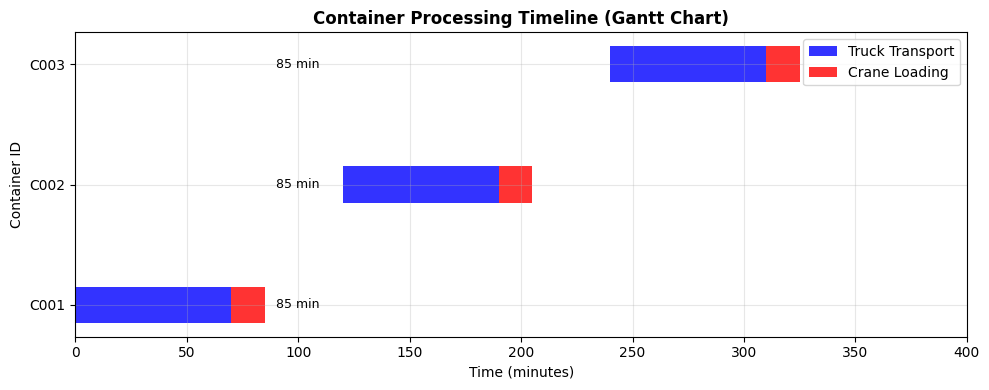

In [7]:
# Data for Gantt chart
def plot_container_processing_timeline():
    containers = ['C001', 'C002', 'C003']
    process_times = [85.0, 85.0, 85.0]
    truck_assign_time = [0, 120, 240]
    crane_assign_time = [70, 190, 310]
    train_loaded_time = [85, 205, 325]

    plt.figure(figsize=(10, 4))
    for i, container in enumerate(containers):
        # truck phase
        plt.barh(i, crane_assign_time[i] - truck_assign_time[i], left=truck_assign_time[i],
                 height=0.3, label='Truck Transport' if i==0 else "", color='blue', alpha=0.8)
        # crane phase
        plt.barh(i, train_loaded_time[i] - crane_assign_time[i], left=crane_assign_time[i],
                 height=0.3, label='Crane Loading' if i==0 else "", color='red', alpha=0.8)
        # annotate process time
        plt.text(process_times[i]+5, i, f"{process_times[i]:.0f} min", va='center', fontsize=9)
    plt.yticks(range(len(containers)), containers)
    plt.xlabel("Time (minutes)")
    plt.ylabel("Container ID")
    plt.title("Container Processing Timeline (Gantt Chart)", fontweight='bold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 400)
    plt.tight_layout()
    # plt.savefig("container_gantt_chart.png", dpi=300, bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    plot_container_processing_timeline()

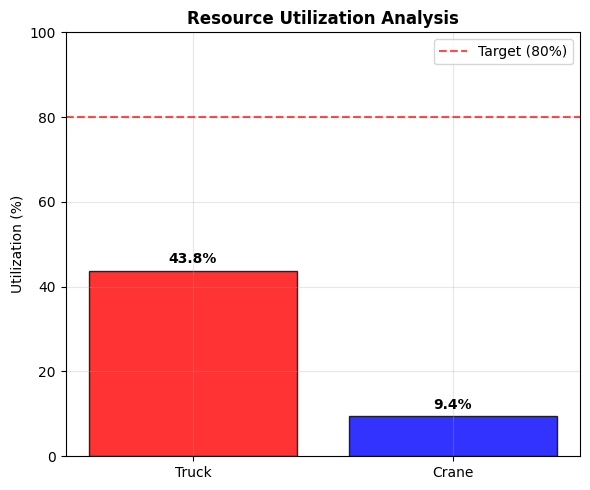

In [8]:
def plot_resource_utilization():
    resources = ['Truck', 'Crane']
    utilization = [43.8, 9.4]  # replace with actual if needed
    colors = ['red', 'blue']
    plt.figure(figsize=(6, 5))
    bars = plt.bar(resources, utilization, color=colors, alpha=0.8, edgecolor='black')
    plt.ylabel("Utilization (%)")
    plt.ylim(0, 100)
    plt.title("Resource Utilization Analysis", fontweight='bold')
    for bar, util in zip(bars, utilization):
        plt.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1,
                 f"{util:.1f}%", ha='center', va='bottom', fontweight='bold')
    plt.axhline(y=80, color='red', linestyle='--', alpha=0.7, label='Target (80%)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_resource_utilization()

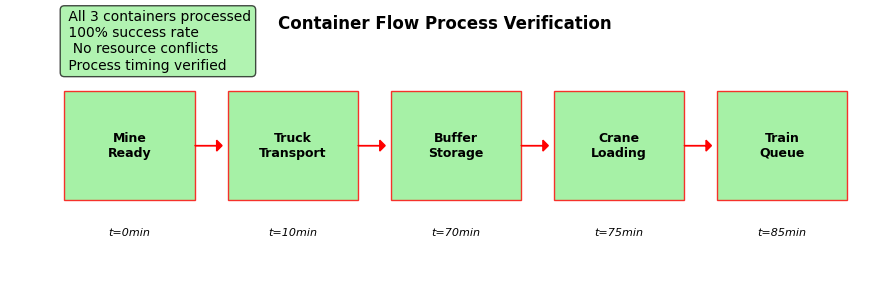

In [9]:
def plot_process_flow_diagram():
    import matplotlib.pyplot as plt
    plt.figure(figsize=(9, 3))
    process_steps = ['Mine\nReady', 'Truck\nTransport', 'Buffer\nStorage', 'Crane\nLoading', 'Train\nQueue']
    step_times = [0, 10, 70, 75, 85]
    ax = plt.gca()
    for i in range(len(process_steps)):
        rect = plt.Rectangle((i*1.5, 0), 1.2, 1, facecolor='lightgreen', edgecolor='red', alpha=0.8)
        ax.add_patch(rect)
        ax.text(i*1.5 + 0.6, 0.5, process_steps[i], ha='center', va='center', fontsize=9, fontweight='bold')
        ax.text(i*1.5 + 0.6, -0.3, f't={step_times[i]}min', ha='center', va='center', fontsize=8, style='italic')
        if i < len(process_steps) - 1:
            ax.arrow(i*1.5 + 1.2, 0.5, 0.2, 0, head_width=0.1, head_length=0.05, fc='red', ec='red')
    ax.set_xlim(-0.5, (len(process_steps)-1)*1.5 + 1.5)
    ax.set_ylim(-0.8, 1.5)
    ax.set_aspect('equal')
    ax.axis('off')
    verification_text = " All 3 containers processed\n 100% success rate\n  No resource conflicts\n Process timing verified"
    ax.text(0, 1.2, verification_text, fontsize=10,
            bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgreen', alpha=0.7))
    plt.title("Container Flow Process Verification", fontweight='bold')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_process_flow_diagram()

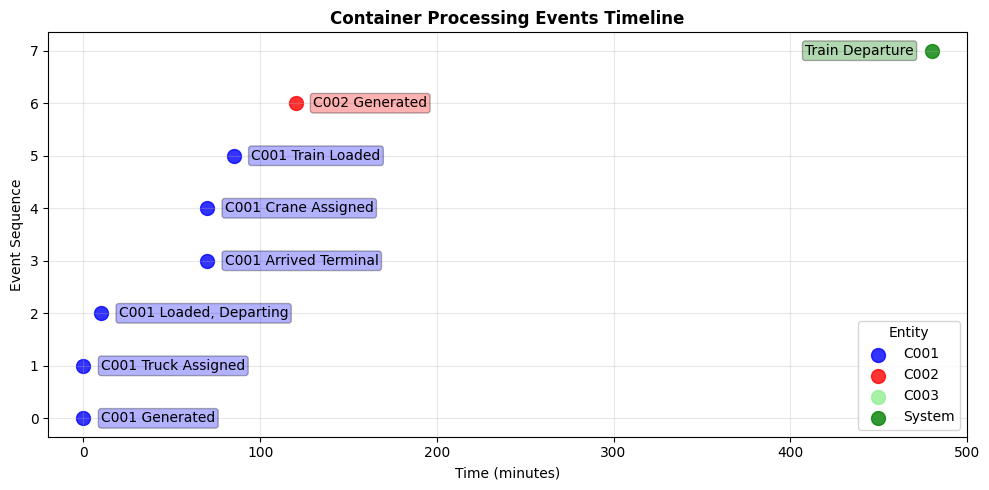

In [10]:
def plot_event_timeline():
    events = [
        (0, 'C001 Generated', 'C001'),
        (0, 'C001 Truck Assigned', 'C001'),
        (10, 'C001 Loaded, Departing', 'C001'),
        (70, 'C001 Arrived Terminal', 'C001'),
        (70, 'C001 Crane Assigned', 'C001'),
        (85, 'C001 Train Loaded', 'C001'),
        (120, 'C002 Generated', 'C002'),
        (480, 'Train Departure', 'System')]
    
    color_map = {'C001': 'blue', 'C002': 'red', 'C003': 'lightgreen', 'System': 'green'}
    plt.figure(figsize=(10, 5))
    for i, (time, event, entity) in enumerate(events):
        plt.scatter(time, i, color=color_map[entity], s=100, alpha=0.8)
        
        if event == "Train Departure":
            plt.text(time-10, i, event, va='center', ha='right', fontsize=10,
                     bbox=dict(boxstyle="round,pad=0.2", facecolor=color_map[entity], alpha=0.3))
        else:
            plt.text(time+10, i, event, va='center', ha='left', fontsize=10,
                     bbox=dict(boxstyle="round,pad=0.2", facecolor=color_map[entity], alpha=0.3))
    plt.xlabel('Time (minutes)')
    plt.ylabel('Event Sequence')
    plt.title('Container Processing Events Timeline', fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.xlim(-20, 500)
    for entity, color in color_map.items():
        plt.scatter([], [], color=color, s=100, alpha=0.8, label=entity)
    plt.legend(title='Entity', loc='lower right')
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    plot_event_timeline()